# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2
from sklearn.preprocessing import OneHotEncoder

# evaluation
import datetime
from tqdm.auto import tqdm as _tqdm

# model visualization
from torchinfo import summary

# reset working dir
import os
from pathlib import Path


In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_24h.parquet")

In [4]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28100,2025-12-31,490872,73,residential,11,10,53.181818,1322.818182,10.206364,27.328182,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
28101,2025-12-31,490872,74,residential,6,5,63.000000,1984.333333,11.760000,33.335000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
28102,2025-12-31,490872,75,residential,14,13,39.545455,1283.214286,11.902857,30.803571,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
28103,2025-12-31,490872,76,airport,1553,824,127.081784,2054.041211,14.628880,38.528210,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     28,105
Unique combinations (no time) :     28,105
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   28,105 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :       77
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :      318  (1.1%)
Non-zero-demand rows           :   27,787  (98.9%)


In [6]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "adam"
LEARNING_RATE      = 5e-5
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}


HP_SEARCH_SEEDS        = (0,)
HP_PATIENCE            = 10
BEST_HP                = {}


## 4.2.3 Model Definition

In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x):
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None):
    set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=_lr)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = _tqdm(train_dl, leave=True, unit="step", disable=not verbose)
        for xb, yb in pbar:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix({"loss": f"{running_loss / n_batches:.4f}"})
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        pbar.set_postfix({"loss": f"{train_loss:.4f}", "val_loss": f"{val_loss:.4f}"})
        pbar.close()
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  device='cpu',
                  lr_candidates=None, seeds=None):
    import itertools

    lr_candidates = lr_candidates or HP_LR_CANDIDATES
    seeds         = seeds         or HP_SEARCH_SEEDS
    arch_label    = ARCH_NAMES.get(arch, str(arch))

    combos = list(itertools.product(lr_candidates))

    print(f'HP Search — {arch_label}')
    print(f'{len(combos)} combos × {len(seeds)} seed(s)'
          f' = {len(combos) * len(seeds)} runs  |  patience={HP_PATIENCE}\n')
    print(f"{{'#':>4}}  {{'lr':>8}}  {{'mean val':>10}}  {{'std':>8}}")
    print('-' * 35)

    results = []
    for i, (lr,) in enumerate(combos, 1):
        val_losses = []
        for seed in seeds:
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                seed=seed, device=device, verbose=False,
                lr=lr, patience=HP_PATIENCE,
            )
            val_losses.append(val_loss)
        mean_loss = float(np.mean(val_losses))
        std_loss  = float(np.std(val_losses))
        results.append({
            'lr': lr,
            'mean_val_loss': mean_loss, 'std_val_loss': std_loss,
        })
        print(f'{i:>4}  {lr:>8.0e}  {mean_loss:>10.4f}  {std_loss:>8.4f}')

    results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
    print(f'\n--- Top 5 ---')
    print(results_df.head(5).to_string(index=False))

    best = results_df.iloc[0]
    BEST_HP[arch] = {'lr': float(best['lr'])}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]

## Evaluation & Save Utilities
Shared helpers used after every training run below: `evaluate_models` computes the test-set metrics for the per-seed models of one architecture and returns the result rows, `save_results` appends them to the results CSV.

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
              f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"\n--- log1p scale ---")
    print(f"{label}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check (MSE, log1p scale) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌──────────────────────┬──────────────────────────────┬─────────────┐
│ pickup_community_area│  is_weekend, temp, rain, ...  │ trip_count  │
│         8            │  0,  12.3,  0.0,  ...        │      5      │
└──────────┬───────────┴───────────────┬───────────────┴──────┬──────┘
           │                           │                       │
           ▼                           ▼                       ▼
     OneHotEncoder               StandardScaler            target y
  area_8=1, rest=0           [0.0, -0.3, ...]               5.0
  (n_ca binary columns)       (n_num scaled columns)
           │                           │
           └──────────────┬────────────┘
                          ▼
                    np.concatenate
         [0, ..., 1, ..., 0,  0.0, -0.3, ...]
               (n_ca + n_num total dims)
                          │
                          ▼
              ┌─────────────────────┐
              │  Linear(dim → 64)   │
              │  ReLU               │
              │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
              │  ReLU               │
              │  Linear(64 → 1)     │
              │  Softplus           │  ← keeps output ≥ 0 (trip count)
              └─────────────────────┘
                          │
                          ▼
                   ŷ  (predicted trip count)
```

Community area identity is encoded as a one-hot vector (fit on training data only).
The network learns a separate weight for each area directly in the first linear layer.

## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [10]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    19,673 rows
Val   :     4,216 rows
Test  :     4,216 rows


In [11]:
train_data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Community Area Encoding

Community area identity is encoded using **one-hot encoding** (fit on the training
set only). Each of the `n_ca` unique areas becomes a binary indicator column,
concatenated with the scaled numeric features before the first linear layer.

This replaces the learnable embedding used in the hexagon notebooks. With only
~77 areas the one-hot representation is compact enough to be practical, and it
has the advantage of being directly interpretable — each area gets its own
explicit weight vector in the first layer.

In [12]:
LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    # 'temperature_2m', 
    'apparent_temperature',
    # 'precipitation',
    # 'rain', 'snowfall',
    # 'wind_speed_10m',
    'cloud_cover', 'is_day', 
    # 'area_km2',
    # 'dist_to_nearest_airport_km',
    'dist_to_nearest_train_station_km',
    # 'dist_to_nearest_stadium_km',
    'train_station_per_km2',
    # 'restaurants_per_km2',
    # 'bars_and_clubs_per_km2',
    # 'hotels_per_km2',
    'hospitals_per_km2',
    'universities_per_km2',
    'attractions_per_km2', 'poi_density_total_per_km2'
    ]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Numeric features (20): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2']


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. univariate feature testing
3. model-based feature importance

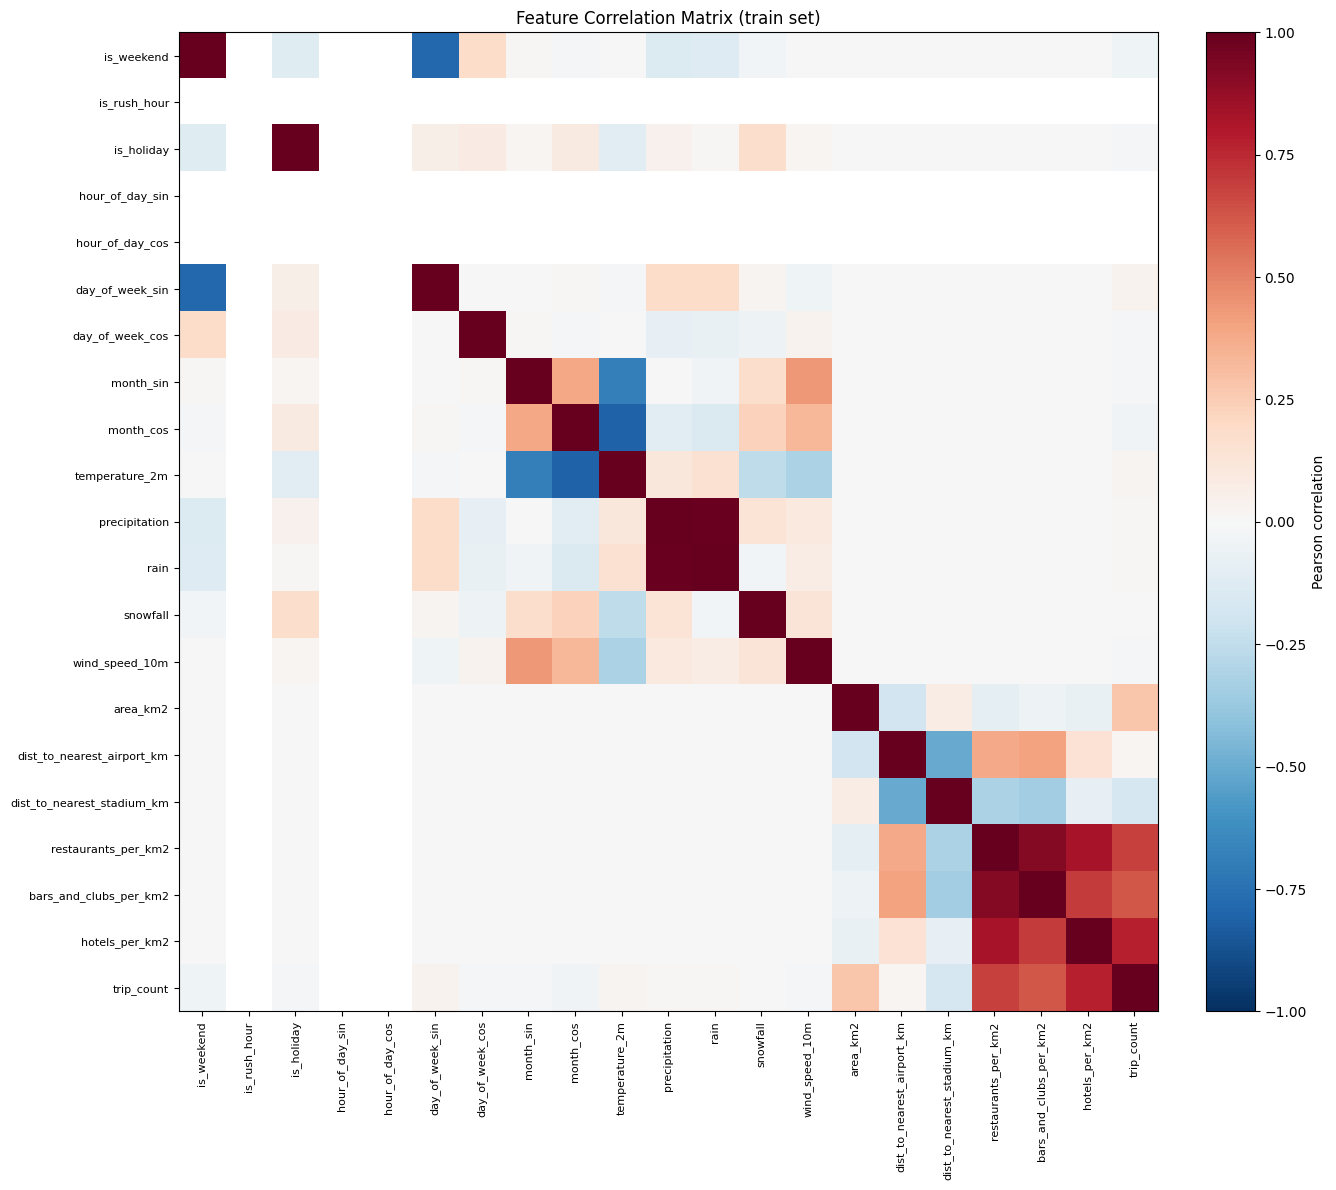

Feature pairs with |correlation| >= 0.8:
  precipitation                       vs rain                                 r=+0.986
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820
  month_cos                           vs temperature_2m                       r=-0.805


In [13]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")


In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Univariate Tests                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.feature_selection import f_regression, mutual_info_regression

X_uni = train_data[FEATURE_COLS].values
y_uni = train_data[TARGET_COL].values

f_scores, f_pvalues = f_regression(X_uni, y_uni)
mi_scores           = mutual_info_regression(X_uni, y_uni, random_state=0)

univariate_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "f_score":     f_scores,
    "f_pvalue":    f_pvalues,
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=False).reset_index(drop=True)

print(univariate_df.to_string(index=False))

# Features with no significant univariate linear relationship (F-test)
ALPHA = 0.05
insignificant = univariate_df.loc[univariate_df["f_pvalue"] > ALPHA, "feature"].tolist()
print(f"\nFeatures with F-test p-value > {ALPHA} (no significant linear relationship with target):")
print(f"  {insignificant if insignificant else 'none'}")


                   feature      f_score      f_pvalue  mutual_info
dist_to_nearest_airport_km     8.682276  3.216962e-03     1.620155
                  area_km2  1622.564227  0.000000e+00     1.603694
dist_to_nearest_stadium_km   596.578248 7.945480e-130     1.589795
       restaurants_per_km2 17242.540125  0.000000e+00     1.471721
    bars_and_clubs_per_km2 12370.624189  0.000000e+00     1.428887
            hotels_per_km2 29971.315273  0.000000e+00     0.651751
                is_weekend    33.420001  7.537988e-09     0.011772
           day_of_week_sin    27.153504  1.898209e-07     0.011091
                  snowfall     0.906383  3.410877e-01     0.008180
           day_of_week_cos     5.728950  1.669677e-02     0.006668
                is_holiday     3.444536  6.347617e-02     0.004216
           hour_of_day_sin     0.000000  1.000000e+00     0.000987
                 month_cos    27.339689  1.724176e-07     0.000386
                 month_sin     2.575678  1.085337e-01     0.00

In [15]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")


                   feature  rf_importance  perm_importance  perm_importance_std
            hotels_per_km2       0.620257         1.295373             0.014737
dist_to_nearest_airport_km       0.131169         0.150784             0.001622
                  area_km2       0.112511         0.095147             0.001052
dist_to_nearest_stadium_km       0.033822         0.042845             0.000582
           day_of_week_sin       0.023779         0.040109             0.001331
                 month_cos       0.012016         0.021055             0.000643
            temperature_2m       0.013166         0.015528             0.000480
                is_weekend       0.011174         0.011674             0.000598
           day_of_week_cos       0.005033         0.009443             0.000654
    bars_and_clubs_per_km2       0.015607         0.008282             0.000158
            wind_speed_10m       0.005235         0.006450             0.000273
                 month_sin       0.00268

In [16]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# One-hot encode community area (fit on train only to avoid leakage)
ohe          = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ca_train_ohe = ohe.fit_transform(train_data[['pickup_community_area']])
ca_val_ohe   = ohe.transform(val_data[['pickup_community_area']])
ca_test_ohe  = ohe.transform(test_data[['pickup_community_area']])

scaler      = StandardScaler()
X_train_num = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val_num   = scaler.transform(val_data[FEATURE_COLS].values)
X_test_num  = scaler.transform(test_data[FEATURE_COLS].values)

X_train = np.concatenate([X_train_num, ca_train_ohe], axis=1)
X_val   = np.concatenate([X_val_num,   ca_val_ohe],   axis=1)
X_test  = np.concatenate([X_test_num,  ca_test_ohe],  axis=1)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

n_ca = ca_train_ohe.shape[1]
print(f"Community area one-hot columns : {n_ca}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Target scale : raw counts (count NLL)
Community area one-hot columns : 77

X_train : (19673, 97)   y_train : (19673,)
X_val   : (4216, 97)     y_val   : (4216,)
X_test  : (4216, 97)    y_test  : (4216,)


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157

Historical mean (area × hour)        R²=0.8676  MAE=60.8814  RMSE=227.1378  NRMSE=1.2653
Ridge regression                     R²=0.8701  MAE=62.7403  RMSE=224.9661  NRMSE=1.2532


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [18]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width)
x_dummy   = torch.zeros(1, input_dim)
summary(viz_model, input_data=x_dummy, col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 97]                   [1]                       1
├─Sequential: 1-1                        [1, 97]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 97]                   [1, 64]                   6,272
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 10,498
Trainable params: 10,498
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 97]                   [1]                       1
├─Sequential: 1-1                        [1, 97]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 97]                   [1, 64]                   6,272
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 10,498
Trainable params: 10,498
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.

In [19]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu



Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 111.6758  val_loss: 119.1692 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

...

  loss: 4.7617  val_loss: 4.7348 ✓
Epoch 199/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.7625  val_loss: 4.7315 ✓
Epoch 200/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.7611  val_loss: 4.7282 ✓

baseline  train: 4.7611 ± 0.0000  val: 4.7282 ± 0.0000


### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [20]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0 layer weight stats:
    net.0.weight    shape=(64, 97)      max|w|=0.6577  mean|w|=0.1272  norm=12.5520
    net.2.weight    shape=(64, 64)      max|w|=0.6174  mean|w|=0.1425  norm=11.4114
    net.4.weight    shape=(1, 64)       max|w|=0.4166  mean|w|=0.1417  norm=1.4269
  seed=0  R²=-2.4362  MAE=191.1250  NRMSE=6.4454  | log  R²=0.5155  MAE=0.8354  NRMSE=0.3684  | zeros 0/67  false=0  | pred min=2.7 max=42156.3

--- original scale ---
Baseline  R²    : -2.4362 ± 0.0000
Baseline  MAE   : 191.1250 ± 0.0000
Baseline  RMSE  : 1157.0532 ± 0.0000
Baseline  NRMSE : 6.4454 ± 0.0000

--- log1p scale ---
Baseline  R²    : 0.5155 ± 0.0000
Baseline  MAE   : 0.8354 ± 0.0000
Baseline  RMSE  : 1.1718 ± 0.0000
Baseline  NRMSE : 0.3684 ± 0.0000

--- zero-demand ---
Baseline  Correct-zero : 0.0 ± 0.0  (out of 67)
Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction r

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [21]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (25 columns)
          timestamp   loss    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2        mae        rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation
2026-07-13T19:52:35 nb_nll baseline         2     64        0.00005        1024     0  4.728192                 67   179.515655 -2.436181 191.125018 1157.053234 6.445417 0.515536 0.835364  1.171763   0.368429             0           0  2.726539 42156.257812                   NaN              relu


## 4.2.10 Hyperparameter Search — Baseline Model

Grid search over 4 hyperparameters using the best LR from the LR search above.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_BASELINE]`.


In [22]:
# HP search candidates — Baseline (2 layers × 64 units)
# Narrow range first; widen if best LR sits at an edge
# LR_CANDIDATES_BASELINE = [2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4, 2e-4, 3e-4, 5e-4]
# LR_CANDIDATES_BASELINE = [6e-5, 7e-5, 1e-4, 2e-4, 3e-4, 5e-4]
# LR_CANDIDATES_BASELINE = [7e-5, 8e-5, 9e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3, 2e-3, 5e-3]
LR_CANDIDATES_BASELINE = [7e-3, 8e-3, 9e-3, 1e-2, 2e-2, 5e-2, 6e-2, 7e-2]

In [23]:
run_hp_search(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_BASELINE,
)

HP Search — baseline
8 combos × 1 seed(s) = 8 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     7e-03      3.9408    0.0000
   2     8e-03      3.9235    0.0000
   3     9e-03      3.9206    0.0000
   4     1e-02      3.9247    0.0000
   5     2e-02      3.9298    0.0000
   6     5e-02         inf       nan
   7     6e-02         inf       nan
   8     7e-02         inf       nan

--- Top 5 ---
   lr  mean_val_loss  std_val_loss
0.009       3.920597           0.0
0.008       3.923537           0.0
0.010       3.924653           0.0
0.020       3.929833           0.0
0.007       3.940819           0.0

BEST_HP[baseline] = {'lr': 0.009}


/Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)


{'lr': 0.009}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [24]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.009}

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 15.0220  val_loss: 6.6007 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 5.9045  val_loss: 5.0462 ✓
Epoch   3/200


...

  loss: 3.6104  val_loss: 3.9486  (no improvement 8/10)
Epoch  89/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 3.5920  val_loss: 3.9313  (no improvement 9/10)
Epoch  90/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 3.5946  val_loss: 3.9431  (no improvement 10/10)

  ↳ early stop at epoch 90  best_val=3.9206  best_train=3.6715

baseline  train: 3.6715 ± 0.0000  val: 3.9206 ± 0.0000


### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [25]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.6677  MAE=80.2860  NRMSE=2.0044  | log  R²=0.8560  MAE=0.4554  NRMSE=0.2009  | zeros 0/67  false=0  | pred min=0.9 max=11254.9

--- original scale ---
Tuned Baseline  R²    : 0.6677 ± 0.0000
Tuned Baseline  MAE   : 80.2860 ± 0.0000
Tuned Baseline  RMSE  : 359.8220 ± 0.0000
Tuned Baseline  NRMSE : 2.0044 ± 0.0000

--- log1p scale ---
Tuned Baseline  R²    : 0.8560 ± 0.0000
Tuned Baseline  MAE   : 0.4554 ± 0.0000
Tuned Baseline  RMSE  : 0.6389 ± 0.0000
Tuned Baseline  NRMSE : 0.2009 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 0.8950 ± 0.0000
Baseline  Pred max : 11254.8574 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0      

In [26]:
results_df

,timestamp,loss,model,n_layers,width,learning_rate,batch_size,seed,hidden_activation,val_loss,...,rmse,nrmse,r2_log,mae_log,rmse_log,nrmse_log,correct_zero,false_zero,pred_min,pred_max
0,2026-07-13T19:52:35,nb_nll,baseline,2,64,0.00005,1024,0,relu,4.728192,...,1157.053234,6.445417,0.515536,0.835364,1.171763,0.368429,0,0,2.726539,42156.257812


In [27]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (25 columns)
          timestamp   loss          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation
2026-07-13T19:54:10 nb_nll baseline_tuned         2     64          0.009        1024     0  3.920597                 67   179.515655 0.667689 80.285952 359.821958 2.004404 0.855968 0.455413  0.638909   0.200888             0           0  0.894966 11254.857422                   NaN              relu


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [28]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 92.8547  val_loss: 92.1750 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 70.9140  val_loss: 72.8681 ✓
Epoch   3/200


...

  loss: 4.5418  val_loss: 4.5132 ✓
Epoch 199/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.5299  val_loss: 4.5123 ✓
Epoch 200/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.5389  val_loss: 4.5115 ✓

deep  train: 4.5389 ± 0.0000  val: 4.5115 ± 0.0000


### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [29]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test,
    device=device,
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=-78.7726  MAE=418.4365  NRMSE=31.0556  | log  R²=0.6159  MAE=0.6932  NRMSE=0.3281  | zeros 0/67  false=0  | pred min=1.6 max=201284.3

--- original scale ---
Deep  R²    : -78.7726 ± 0.0000
Deep  MAE   : 418.4365 ± 0.0000
Deep  RMSE  : 5574.9643 ± 0.0000
Deep  NRMSE : 31.0556 ± 0.0000

--- log1p scale ---
Deep  R²    : 0.6159 ± 0.0000
Deep  MAE   : 0.6932 ± 0.0000
Deep  RMSE  : 1.0434 ± 0.0000
Deep  NRMSE : 0.3281 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 0.0 ± 0.0  (out of 67)
Deep  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 1.6481 ± 0.0000
Deep  Pred max : 201284.3438 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       4.5389    4.5115    1.0887


In [30]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (25 columns)
          timestamp   loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual         r2       mae        rmse     nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation
2026-07-13T19:54:34 nb_nll  deep         8     64        0.00005        1024     0   4.51153                 67   179.515655 -78.772563 418.43654 5574.964326 31.055589 0.615868 0.693199  1.043397   0.328068             0           0  1.648121 201284.34375                   NaN              relu


## 4.2.12 Hyperparameter Search — Deeper Model

Same grid search as for the baseline, run on `ARCH_DEEPER = (4 hidden layers, 64 units)`.
Result is stored in `BEST_HP[ARCH_DEEPER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_DEEPER]`.

In [31]:
# HP search candidates — Deeper (4 layers × 64 units)
# Deeper networks often need a smaller LR to stay stable
# LR_CANDIDATES_DEEPER   = [7e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3]
LR_CANDIDATES_DEEPER = [2e-4, 3e-4, 5e-4, 7e-4, 8e-4, 9e-4, 1e-3, 2e-3, 5e-3, 6e-3, 7e-3]

In [32]:
run_hp_search(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_DEEPER,
)

HP Search — deep
11 combos × 1 seed(s) = 11 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     2e-04      4.3756    0.0000
   2     3e-04      4.3265    0.0000
   3     5e-04      4.2270    0.0000
   4     7e-04      4.2095    0.0000
   5     8e-04      4.1482    0.0000
   6     9e-04      4.1246    0.0000
   7     1e-03      4.1033    0.0000
   8     2e-03      4.0150    0.0000
   9     5e-03      3.9669    0.0000
  10     6e-03      3.9579    0.0000
  11     7e-03      3.9430    0.0000

--- Top 5 ---
   lr  mean_val_loss  std_val_loss
0.007       3.943029           0.0
0.006       3.957909           0.0
0.005       3.966912           0.0
0.002       4.014992           0.0
0.001       4.103284           0.0

BEST_HP[deep] = {'lr': 0.007}


{'lr': 0.007}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [33]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} \u00b1 {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} \u00b1 {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.007}

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 13.4584  val_loss: 5.3081 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 5.0707  val_loss: 4.7438 ✓
Epoch   3/200


...

  loss: 3.6370  val_loss: 3.9717  (no improvement 8/10)
Epoch  94/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 3.6314  val_loss: 4.1166  (no improvement 9/10)
Epoch  95/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 3.6243  val_loss: 4.0003  (no improvement 10/10)

  ↳ early stop at epoch 95  best_val=3.9430  best_train=3.6524

deep  train: 3.6524 ± 0.0000  val: 3.9430 ± 0.0000


### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [34]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.7272  MAE=76.6048  NRMSE=1.8162  | log  R²=0.8650  MAE=0.4578  NRMSE=0.1945  | zeros 4/67  false=24  | pred min=0.1 max=9274.1

--- original scale ---
Tuned Deeper  R²    : 0.7272 ± 0.0000
Tuned Deeper  MAE   : 76.6048 ± 0.0000
Tuned Deeper  RMSE  : 326.0306 ± 0.0000
Tuned Deeper  NRMSE : 1.8162 ± 0.0000

--- log1p scale ---
Tuned Deeper  R²    : 0.8650 ± 0.0000
Tuned Deeper  MAE   : 0.4578 ± 0.0000
Tuned Deeper  RMSE  : 0.6185 ± 0.0000
Tuned Deeper  NRMSE : 0.1945 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 4.0 ± 0.0  (out of 67)
Tuned Deeper  False-zero   : 24.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0836 ± 0.0000
Deep  Pred max : 9274.1201 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.6524    3.9430    0.3826


In [35]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (25 columns)
          timestamp   loss      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation
2026-07-13T19:57:21 nb_nll deep_tuned         8     64          0.007        1024     0  3.943029                 67   179.515655 0.727174 76.604791 326.030644 1.816168 0.865011 0.457766  0.618526   0.194479             4          24  0.083578 9274.120117                   NaN              relu


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [36]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 129.4020  val_loss: 90.2441 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 70.6997  val_loss: 51.5320 ✓
Epoch   3/200


...

  loss: 4.5141  val_loss: 4.4357 ✓
Epoch 199/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.5176  val_loss: 4.4353 ✓
Epoch 200/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.5144  val_loss: 4.4349 ✓

wide  train: 4.5144 ± 0.0000  val: 4.4349 ± 0.0000


### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [37]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test,
    device=device,
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=-165.9868  MAE=501.8963  NRMSE=44.9318  | log  R²=0.6111  MAE=0.5840  NRMSE=0.3301  | zeros 0/67  false=0  | pred min=0.9 max=378242.7

--- original scale ---
Wide  R²    : -165.9868 ± 0.0000
Wide  MAE   : 501.8963 ± 0.0000
Wide  RMSE  : 8065.9665 ± 0.0000
Wide  NRMSE : 44.9318 ± 0.0000

--- log1p scale ---
Wide  R²    : 0.6111 ± 0.0000
Wide  MAE   : 0.5840 ± 0.0000
Wide  RMSE  : 1.0499 ± 0.0000
Wide  NRMSE : 0.3301 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 0.0 ± 0.0  (out of 67)
Wide  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.9033 ± 0.0000
Wide  Pred max : 378242.6875 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       4.5144    4.4349    1.1022


In [38]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (25 columns)
          timestamp   loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual          r2        mae        rmse     nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation
2026-07-13T19:57:40 nb_nll  wide         2    256        0.00005        1024     0  4.434947                 67   179.515655 -165.986819 501.896325 8065.966547 44.931828 0.611088  0.58403  1.049868   0.330102             0           0  0.903268 378242.6875                   NaN              relu


### 4.2.12 Hyperparameter Search — Wider Model

Same grid search as for the baseline, run on `ARCH_WIDER = (2 hidden layers, 128 units)`.
Result is stored in `BEST_HP[ARCH_WIDER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_WIDER]`.

In [39]:
# HP search candidates — Wider (2 layers × 128 units)
# More parameters → can tolerate slightly higher LR than deeper
LR_CANDIDATES_WIDER    = [8e-5, 9e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 8e-4, 9e-4, 1e-3, 2e-3, 5e-3]

In [40]:
run_hp_search(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_WIDER,
)

HP Search — wide
12 combos × 1 seed(s) = 12 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     8e-05      4.4239    0.0000
   2     9e-05      4.4199    0.0000
   3     1e-04      4.4158    0.0000
   4     2e-04      4.3704    0.0000
   5     3e-04      4.3245    0.0000
   6     5e-04      4.2389    0.0000
   7     7e-04      4.1592    0.0000
   8     8e-04      4.1201    0.0000
   9     9e-04      4.0888    0.0000
  10     1e-03      4.0560    0.0000
  11     2e-03      3.9384    0.0000
  12     5e-03      3.9286    0.0000

--- Top 5 ---
    lr  mean_val_loss  std_val_loss
0.0050       3.928577           0.0
0.0020       3.938385           0.0
0.0010       4.056037           0.0
0.0009       4.088753           0.0
0.0008       4.120086           0.0

BEST_HP[wide] = {'lr': 0.005}


{'lr': 0.005}

### 4.2.12 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [41]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.005}

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 17.8948  val_loss: 9.4339 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 6.9517  val_loss: 5.4090 ✓
Epoch   3/200


...

  loss: 3.6320  val_loss: 3.9593  (no improvement 8/10)
Epoch 121/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 3.6307  val_loss: 3.9387  (no improvement 9/10)
Epoch 122/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 3.6186  val_loss: 3.9487  (no improvement 10/10)

  ↳ early stop at epoch 122  best_val=3.9286  best_train=3.6996

wide  train: 3.6996 ± 0.0000  val: 3.9286 ± 0.0000


### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [42]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=-0.0118  MAE=100.0057  NRMSE=3.4975  | log  R²=0.8315  MAE=0.4563  NRMSE=0.2173  | zeros 0/67  false=2  | pred min=0.4 max=25061.0

--- original scale ---
Tuned Wider  R²    : -0.0118 ± 0.0000
Tuned Wider  MAE   : 100.0057 ± 0.0000
Tuned Wider  RMSE  : 627.8633 ± 0.0000
Tuned Wider  NRMSE : 3.4975 ± 0.0000

--- log1p scale ---
Tuned Wider  R²    : 0.8315 ± 0.0000
Tuned Wider  MAE   : 0.4563 ± 0.0000
Tuned Wider  RMSE  : 0.6911 ± 0.0000
Tuned Wider  NRMSE : 0.2173 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Wider  False-zero   : 2.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.4495 ± 0.0000
Wide  Pred max : 25061.0293 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.6996    3.9286    0.4776


In [43]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (25 columns)
          timestamp   loss       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation
2026-07-13T20:00:38 nb_nll wider_tuned         2    256          0.005        1024     0  3.928577                 67   179.515655 -0.011811 100.005694 627.863323 3.497541 0.831475 0.456282  0.691101   0.217298             0           2   0.44946 25061.029297                   NaN              relu


## 4.2.13 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 191.0463
Empirical variance          : 384554.8309
Dispersion (var / mean)     : 2012.8882  (overdispersed)
Mean Poisson NLL @ lambda_hat: -812.4274  (up to const. log(y!))


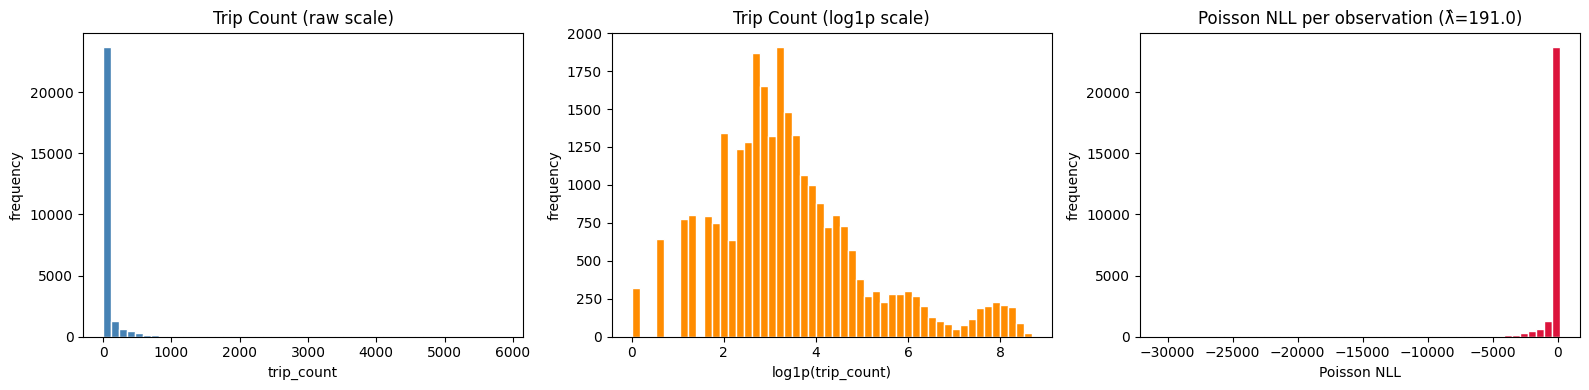

In [44]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (\u03bb\u0302={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()